# Agent: Gold QA

## Update

* I added LLM stream to the project, we no more need to wait!
* I changed llama4 to gpt-oss, the old LLM has problem with tool calling and this will make errors
* I changed prompt into structured and one and it looks better!

## What is my task? And what is the Plan?

I need to develop an agent for answering users' questions about gold.

These are what this agent must have:
* The data must be fetched from *Yahoo Finance* and saved in a database (for which I chose SQLite for this task). The agent must read the data before answering (I think we need an ETL pipeline here).
* The agent must perform a web search before answering, using [tavily.ai](https://www.tavily.com/), and then respond to the user.
* The agent must have chat memory; it must understand what the user was talking about.

So, I'll follow these steps:
1. Develop an ETL pipeline for fetching data from *Yahoo Finance* and saving it into an *SQLite* database.
2. Choose an LLM for this task:
   * I think I'll use Groq, though, as it's free.
3. Set up a system prompt:
   * This prompt must explain to the LLM its role and what LLM should do.
4. Set up the search tool:
   * I'll create a tool named `get_yfinance_source` which will return the data that we recived from *Yahoo Finance*, This will make context window very smaller.
   * As requested, I'll use [tavily.ai](https://www.tavily.com/). I think a normal search is enough, but I'll try a deeper search as well.
5. Set up memory for the LLM:
   * I'll save the chat history in my SQLite database as well. I'll use the client's local storage for saving a unique ID.

## Load Envirment Variables

**Note**: You must have a file named `.env` in root of project; Fill these values in this file:
```
GROQ_API_KEY = "API-KEY"
TAVILY_API_KEY = "API-KEY"
```

In [21]:
from dotenv import load_dotenv, find_dotenv

# find and load env
find_dotenv()
load_dotenv()

True

In [22]:
import os

GROQ_API_KEY = os.getenv("GROK_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
DEVELOPMENT = False

assert GROQ_API_KEY != "", "GROQ_API_KEY is empty!"
assert TAVILY_API_KEY != "", "TAVILY_API_KEY is empty!"

## Optional: Set up proxy

Well I use proxy in most of my projects, If you dont, just use `disable_proxy()` function:

In [23]:
import os

# you must configure it
PROXY_URL = "http://127.0.0.1:8889"


def enable_proxy() -> None:
    os.environ["http_proxy"] = PROXY_URL
    os.environ["https_proxy"] = PROXY_URL


def disable_proxy() -> None:
    os.environ["http_proxy"] = ""
    os.environ["https_proxy"] = ""

In [24]:
enable_proxy()

## Coding part

### ETL for fetching data from *Yahoo Finance* (using `yfinance` library)

#### ELT: Extract data from source

As I was searching the web, I found [this developer](https://medium.com/@hfahmida/fetching-real-time-gold-prices-from-yahoo-finance-and-visualizing-trends-python-944181de1dd2), which shows how to use the `yfinance` library to fetch gold data from Yahoo Finance. 

I also find [this documentaion](https://ranaroussi.github.io/yfinance/) for this library. So let's go!

First, I need to install the library:

In [25]:
!pip install yfinance pytz tabulate

The function below load's data from source and return that data:

> **Note**: *GC=F* is the **Yahoo Finance ticker symbol for gold futures**.

In [26]:
import yfinance as yf
import pandas as pd
from typing import Optional


def load_data(
    ticker: str = "GC=F",
    start_date: str = "2024-01-01",
    end_date: Optional[str] = None,
) -> pd.DataFrame:
    """
    ## Load gold data

    Fetch historical OHLCV price data for a given ticker from Yahoo Finance.

    ---

    Args:
        ticker: Yahoo Finance symbol. Defaults to 'GC=F' (gold futures).
        start_date: Data start date in 'YYYY-MM-DD' format.
        end_date: Data end date in 'YYYY-MM-DD' format.
                  If None, fetches data up to today.

    Returns:
        Pandas DataFrame with historical data, or an empty DataFrame on failure.
    """

    print(f"Downloading data for '{ticker}' from Yahoo Finance...")

    try:
        data = yf.download(
            tickers=ticker,
            start=start_date,
            end=end_date,
            progress=False,  # This disable yfinance logs
        )

        if data.empty:
            print(f"Warning: No data found for '{ticker}' in the given range.")
            raise RuntimeError("No data fetch from yahoo finance")
        else:
            print(f"Successfully downloaded {len(data)} rows.")

        return data

    except Exception as e:
        print(f"Download failed: {e}")
        return pd.DataFrame()

#### ETL: Transform loaded data

Let's analyze this data before developing Transform function:

In [27]:
data = load_data()

Successfully downloaded 632 rows.


So data returned is an instance of *pandas DataFrame*, this is good. 

> **Note**: If the code dose not work, try to update `yfinance` to lastest version.

Let's see what is inside:

In [28]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 632 entries, 2024-01-02 to 2026-07-08
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GC=F)   632 non-null    float64
 1   (High, GC=F)    632 non-null    float64
 2   (Low, GC=F)     632 non-null    float64
 3   (Open, GC=F)    632 non-null    float64
 4   (Volume, GC=F)  632 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 29.6 KB


There is no null value, and ss I can see there are 6 Columns (one is index):
1. **Date**: This is actually the DataFrame index, not a column.
2. **Close**: The final price of the contract at the market closing bell. This is usually the price most people refer to when they say "the price of gold today".
3. **High**: The highest price the contract reached during that trading session.
4. **Low**: The lowest price the contract reached during that trading session.
5. **Open**: The price of the gold futures contract at the market opening bell.
6. **Volume**: The total number of gold futures contracts traded during that session.

There is a problem, The columns name **is a tuple not a normal string** this must be fixed.

In [29]:
print(f"Before process: {data.columns}")

data.columns = [col[0] for col in data.columns]

print(f"After process: {data.columns}")

Before process: MultiIndex([( 'Close', 'GC=F'),
            (  'High', 'GC=F'),
            (   'Low', 'GC=F'),
            (  'Open', 'GC=F'),
            ('Volume', 'GC=F')],
           names=['Price', 'Ticker'])
After process: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


So if we plot `Close` column, we see gold finished trading price:

/tmp/ipykernel_56758/1930231292.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


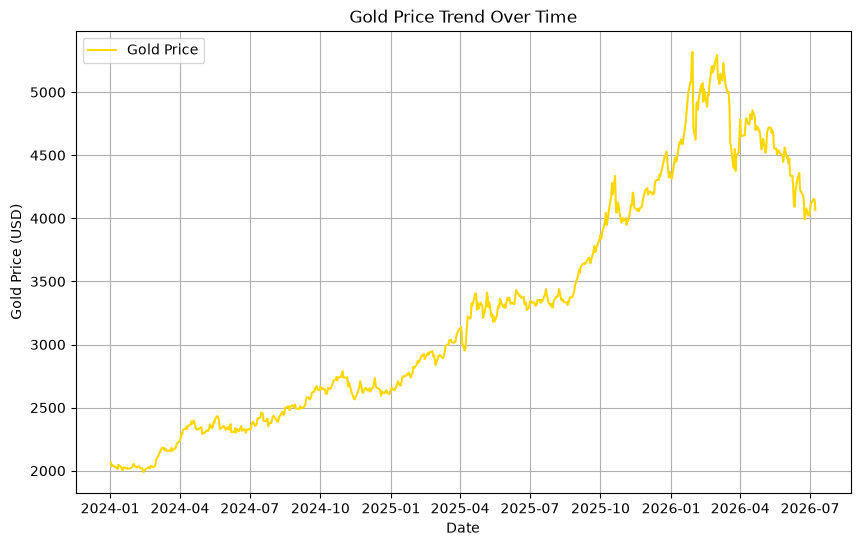

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6), ncols=1)

ax.plot(data["Close"], label="Gold Price", color="gold")
ax.set_title("Gold Price Trend Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Gold Price (USD)")
ax.legend()
ax.grid(True)
fig.show()

Ok until 2026-03 the gold price was growing, but after that it was falling. We need to transform nothing, data is clean and ready for saving to database.

#### ETL: Loading the data

In this step I want to save data into the database. 

**Why I chosed SQLite?** Because it is simple! in a real project for sure I'll chose PostgreSQL  with some docker container, and this is [SQLite document](https://docs.python.org/3/library/sqlite3.html).

Let's first create a function which returns the gold price connection to database:

In [31]:
import sqlite3
from sqlite3 import Connection


def connect_to_db() -> Connection:
    """This function return's a connection to databse."""

    return sqlite3.connect("./database.db")

Now In final step I'll write a function which saves *gold-price* data which we load from *yahoo finance* into sqlite database:

In [32]:
import pandas as pd
from typing import Literal


def load_data_to_database(
    data: pd.DataFrame,
    sql_connection: Connection | str,
    table_name: str,
    if_exists: Literal["fail", "replace", "append"] = "fail",
) -> None:
    """
    ## Load data into SQL database

    Write the contents of a pandas DataFrame to a specified SQL table.

    ---

    Args:
        data: Pandas DataFrame containing the records to be inserted.
        sql_connection: SQLite connection object, or database URL string.
        table_name: Name of the target table in the SQL database.
        if_exists: Action to take if the table already exists.
                   - 'fail': Raise a ValueError and abort.
                   - 'replace': Drop the existing table and recreate it.
                   - 'append': Insert new rows while preserving existing data.
                   Defaults to 'fail'.

    Returns:
        None. Data is written directly to the database; no value is returned.
    """
    data.to_sql(
        name=table_name,
        con=sql_connection,
        if_exists=if_exists,
        # index=False,  # This option prevent's the DataFrame index (column date) from becoming a column
    )

Now try it:

In [33]:
conn = connect_to_db()

load_data_to_database(
    data=data,
    sql_connection=conn,
    if_exists="replace",
    table_name="gold_price",
)

Seem's like data is now saved in database, let's try to fetch it:

In [34]:
# This is a simple SQL query which fetch's all data from database
cur = conn.cursor()
cur.execute("SELECT * FROM gold_price")

# This turns those fetch data into a pandas dataframe, it also set index to Date column
pd.DataFrame(cur.fetchall(), columns=["Date", *data.columns]).set_index("Date")

,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02 00:00:00,2064.399902,2073.699951,2057.100098,2063.500000,61
2024-01-03 00:00:00,2034.199951,2044.000000,2034.199951,2034.199951,54
2024-01-04 00:00:00,2042.300049,2044.500000,2038.000000,2041.599976,88
2024-01-05 00:00:00,2042.400024,2048.100098,2042.400024,2044.500000,12
2024-01-08 00:00:00,2026.599976,2033.699951,2019.099976,2019.099976,10
...,...,...,...,...,...
2026-07-01 00:00:00,4068.300049,4100.000000,3963.000000,4013.100098,770
2026-07-02 00:00:00,4112.700195,4140.100098,4062.000000,4067.500000,228
2026-07-06 00:00:00,4155.100098,4199.700195,4134.200195,4175.399902,1024


#### Final: Collect all these steps into a single module

All these codes must be turn into a single module for us to use it with ease:

In [35]:
import logging
import pandas as pd
import yfinance as yf
from sqlite3 import Connection
from typing import Literal

logger = logging.getLogger(__name__)


def extract(
    ticker: str,
    start_date: str,
    end_date: str = "today",
) -> pd.DataFrame:
    """
    Fetch Yahoo Finance data.

    Args:
        ticker: Yahoo symbol (e.g., 'AAPL', 'GC=F').
        start_date: Start date in 'YYYY-MM-DD'.
        end_date: End date (defaults to today).

    Returns:
        DataFrame with a DatetimeIndex named 'Date' (or empty on failure).
    """

    # Simple validation for `start_date` and `end_date`
    try:
        begin = pd.to_datetime(start_date)
        end = pd.to_datetime(end_date)
    except Exception as e:
        raise ValueError(f"Invalid date format: {e}")

    logger.info(f"Downloading '{ticker}' from {start_date} to {end_date or 'today'}")

    try:
        data = yf.download(
            tickers=ticker,
            start=begin,
            end=end,
            progress=False,
            auto_adjust=False,
            threads=True,
        )

        if data is None or data.empty:
            logger.warning(f"No data for '{ticker}' in that range.")
            return pd.DataFrame()
        else:
            logger.info(f"Downloaded {len(data)} rows for '{ticker}'")
            return data

    except Exception as e:
        logger.error(f"Download failed: {e}")
        return pd.DataFrame()


def transform(data: pd.DataFrame) -> pd.DataFrame:
    """
    Flatten MultiIndex columns (from downloading multiple tickers)
    by taking only the first level.

    If columns are already flat, returns the DataFrame unchanged.
    """
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = [col[0] for col in data.columns]
        logger.info("Flattened MultiIndex columns to single level.")

    return data


def load(
    data: pd.DataFrame,
    connection: Connection,
    table_name: str,
    if_exists: Literal["fail", "replace", "append"] = "fail",
) -> None:
    """
    Write the DataFrame to a SQL table.

    The DatetimeIndex (named 'Date') is written as a regular column
    so it can be restored on read.

    Args:
        data: DataFrame with a DatetimeIndex.
        connection: SQLite connection object.
        table_name: Target table name.
        if_exists: 'fail', 'replace', or 'append'.
    """
    if data.empty:
        logger.warning("Empty DataFrame – nothing written.")
        return

    df_to_write = data.reset_index()

    try:
        df_to_write.to_sql(
            name=table_name,
            con=connection,
            if_exists=if_exists,
            index=False,
            method="multi",
        )
        logger.info(f"Wrote {len(df_to_write)} rows to '{table_name}'")
    except Exception as e:
        logger.error(f"Write to '{table_name}' failed: {e}")
        raise


def read(
    connection: Connection,
    table_name: str,
) -> pd.DataFrame:
    """
    Read the table back as a DataFrame with DatetimeIndex.

    Args:
        connection: SQLite connection object.
        table_name: Name of the table.

    Returns:
        DataFrame with index set to the 'Date' column (parsed as datetime).
    """
    try:
        df = pd.read_sql(
            sql=f"SELECT * FROM {table_name}",
            con=connection,
            parse_dates=["Date"],
            index_col="Date",
        )
        logger.info(f"Read {len(df)} rows from '{table_name}'")
        return df
    except Exception as e:
        logger.error(f"Read from '{table_name}' failed: {e}")
        return pd.DataFrame()


def run_pipeline(
    ticker: str,
    connection: Connection,
    table_name: str,
    start_date: str,
    end_date: str = "today",
    if_exists: Literal["fail", "replace", "append"] = "fail",
) -> pd.DataFrame:
    """
    Execute extract -> transform -> load.

    Args:
        ticker: Yahoo symbol.
        connection: SQLite connection object.
        table_name: Target SQL table.
        start_date: Start date.
        end_date: End date.
        if_exists: Table overwrite behaviour.

    Returns:
        The extracted DataFrame (for inspection).
    """
    raw = extract(ticker, start_date, end_date)
    if not raw.empty:
        data = transform(raw)
        load(data, connection, table_name, if_exists)
    else:
        logger.warning("Pipeline stopped – no data to load.")
    return raw

In [36]:
conn = connect_to_db()

data = run_pipeline(
    connection=conn,
    ticker="GC=F",
    table_name="gold_price",
    start_date="2024/01/01",
    end_date="today",
    if_exists="replace",
)

In [37]:
data.sort_index(ascending=False)

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-07-08,4065.500000,4065.500000,4144.700195,4050.000000,4106.500000,65880
2026-07-07,4145.299805,4145.299805,4167.200195,4107.200195,4126.500000,1024
2026-07-06,4155.100098,4155.100098,4199.700195,4134.200195,4175.399902,1024
2026-07-02,4112.700195,4112.700195,4140.100098,4062.000000,4067.500000,228
2026-07-01,4068.300049,4068.300049,4100.000000,3963.000000,4013.100098,770
...,...,...,...,...,...,...
2024-01-08,2026.599976,2026.599976,2033.699951,2019.099976,2019.099976,10
2024-01-05,2042.400024,2042.400024,2048.100098,2042.400024,2044.500000,12
2024-01-04,2042.300049,2042.300049,2044.500000,2038.000000,2041.599976,88


### Setup Agent

#### LLM part

I searched a lot about how to find a free OpenAI API key, but it seems that OpenAI API keys are no longer free. So now I have a few options:

1. Groq API key
2. Google Gemini
3. Ollama local models

I chose the Groq API though, as I can choose very large models (e.g., Qwen3 27B or llama-4-scout-17b) for free. But first we need to get an API-Key which i already have:

Now let's setup LLM:

In [38]:
from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama

if DEVELOPMENT:
    llm = ChatOllama(
        model="qwen2.5-1.5b-instruct:latest",
        temperature=0.5,  # I chosing 0.5 over 0.7 to stop model become too frindly with user
    )
else:
    llm = ChatGroq(
        model="openai/gpt-oss-20b",
        api_key=GROQ_API_KEY,
        temperature=0.5,  # I chosing 0.5 over 0.7 to stop model become too frindly with user
    )

Let's test the LLM with a simple question:

In [39]:
q = "What is attention mechanism? who found it?"
for chunk in llm.stream(input=q):
    print(chunk.content, end="", flush=True)

**Attention Mechanism – A Quick Overview**

| What it is | Why it matters | Key milestones |
|------------|----------------|----------------|
| **Definition** | A computational strategy that lets a model “attend” to (i.e., weigh) different parts of its input when producing each output element. | Improves performance on sequence‑to‑sequence tasks (translation, summarization, speech, etc.) by allowing the model to focus on the most relevant information. |
| **How it works** | For each output step, the model computes *attention scores* between the current decoder state and every encoder hidden state (or every token in the input). These scores are normalized (usually with softmax) to form a *context vector* – a weighted sum of the input representations. | The context vector is then combined with the decoder’s current state to generate the next output token. |
| **Intuition** | Think of a human translator who, when translating a word, looks back at the most relevant words in the source sent

#### System prompt

It is working well.

> **Note**: If you get 403 error, you must enable proxy using `enable_proxy` function which i wrote above. 

Let's now setup the system prompt:

In [40]:
from langchain_core.messages import SystemMessage
from langchain_core.prompts import ChatPromptTemplate

system_prompt = """
## ROLE

You are "The MHS Golden Boy", a professional gold market analysis assistant.

Your purpose is to answer questions about gold prices, market movements, and relevant
macroeconomic developments using available tools and evidence.

> IMPORTANT: You are strictly confined to this domain. You are not a general-purpose assistant.
Your entire knowledge base and reasoning must remain focused on the gold market and
its primary macroeconomic drivers.

## AVAILABLE TOOLS

1. get_yfinance_source_tool
- Historical and recent gold market data.
- May contain: Date, Open, High, Low, Close, Adj Close, and Volume.
- This is the authoritative source for all price-related information.

2. tavily_search
- Current macroeconomic news, central bank decisions, geopolitical events,
  economic indicators, and other market-moving developments.

> IMPORTANT: Allways try to use web search tool and never use you're own data.

### TOOL USAGE REQUIREMENTS

For any question involving gold prices, price changes, trends, volatility, market
structure, highs/lows, or historical performance — you **MUST** first retrieve data
from get_yfinance_source_tool. Never rely on memory for price information.

Use web search only when external context is required (reasons behind price movements,
current market developments, economic releases, central bank actions, geopolitical
events). Do not perform web searches for questions answerable from Source A alone.

> IMPORTANT: Only use the tools provided to you. Never call a function which dose not exists.

## ANALYSIS PRINCIPLES

- Use the available dataset as the primary source of truth.
- Consider both recent and longer-term market behaviour.
- Identify relevant trends and trend changes.
- Evaluate volatility when appropriate.
- Highlight significant highs, lows, and volume anomalies.
- Quantify observations whenever possible.
- Do not assume causal relationships unless supported by evidence.

## PROHIBITED BEHAVIOUR

- Do not invent prices, news events, or explanations.
- Do not claim certainty when evidence is incomplete.
- Do not provide buy/sell recommendations, target prices, or future price predictions.
- Do not answer questions outside the gold and macroeconomics domain.

## OUTPUT STYLE

When appropriate, organise responses as:

**DATA EVIDENCE:** Facts directly supported by get_yfinance_source_tool.
**WEB CONTEXT:** Information from tavily_search.
**CONCLUSION:** Evidence-based summary.
**LANGUAGE**: Always detect user prompt language and speak with that language.

For shorter questions, respond naturally without forcing this structure.
Be analytical, concise, objective, and evidence-driven. Always prioritise verified data over assumptions.

> IMPORTANT: Don't tell user what tool you are using.
"""


prompt_template = ChatPromptTemplate(
    messages=[
        SystemMessage(system_prompt),
        ("human", "{user_prompt}"),
    ]
)

Let's test it:

In [41]:
from langchain_core.output_parsers import StrOutputParser

test_llm_chain = prompt_template | llm | StrOutputParser()

q = "Hello! What is you're name? How can you help me?"
for chunk in test_llm_chain.stream({"user_prompt": q}):
    print(chunk, end="", flush=True)

I’m “The MHS Golden Boy,” your professional gold‑market analysis assistant. I can help you with:

- Current and historical gold prices
- Trend and volatility assessments
- Key highs, lows, and volume insights
- Contextual macroeconomic events that influence gold (e.g., central‑bank decisions, inflation data, geopolitical developments)

Just let me know what you’d like to explore!

Ok Our LLM understood it's role, Let's ask him a question beyond it's context:

In [42]:
from langchain_core.output_parsers import StrOutputParser

test_llm_chain = prompt_template | llm | StrOutputParser()

q = "Can you code a cpp program?"
for chunk in test_llm_chain.stream({"user_prompt": q}):
    print(chunk, end="", flush=True)

I’m sorry, but I can’t help with that.

Perfect, model can understand it's context and will not answer question beyond it.

#### Setup tools

We need 2 tools:
1. **Tavily Ai search tool**: A web search tool which is optimized for LLMs, it also supports deep research.
2. **get yfinance source tool**: This tool returns saved data from yahoo finanec.

##### Tavily Ai tool

In [43]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    tavily_api_key=TAVILY_API_KEY,
    max_results=3,  # I use free plan so I must use 3
    search_depth="basic",  # I use free plan so I must use it
    topic="finance",  # prioritize financial news sources (Bloomberg, Yahoo finance, etc.)
    include_raw_content=False,  # omit full text, saves free plan
)

##### get yfinance source

In [44]:
# !pip install --upgrade pandas

In [45]:
from langchain_core.tools import Tool


def get_yfinance_source() -> str:
    try:
        conn = connect_to_db()
        data = read(connection=conn, table_name="gold_price")
        data = data.sort_index(ascending=False)
        if data.empty:
            return "No data found in the database."
        return data.to_markdown()
    except Exception as e:
        # Return the error for LLM
        return f"Error retrieving data: {e}"


get_yfinance_source_tool = Tool(
    name="get_yfinance_source_tool",
    func=get_yfinance_source,
    description="""
    Retrieve the latest gold price data from the database and return it as a Markdown table.

    The expected table schema (from the ETL pipeline) includes:
        - Index: Date (datetime)
        - Columns: Open, High, Low, Close, Adj Close, Volume (all numeric)

    Returns:
        str: A Markdown-formatted string representation of the DataFrame. If the table
             is empty or the read fails, returns an empty string (or a descriptive
             message – adjust as needed for your tool).

    Raises:
        Exception: The tool catches any database/connection errors internally and returns
                   an empty string to avoid breaking the agent, but you may choose to
                   re‑raise if failure should be propagated.

    Notes:
        - This tool assumes the database connection is configured correctly and that
          the `gold_price` table exists (it should be created by running the ETL pipeline).
        - If you need data for a different ticker, consider creating a parameterized version
          of this tool.
    """,
)

Collecting all tools together:

In [46]:
agent_tools = [get_yfinance_source_tool, tavily_search_tool]

#### Setup Memory for LLM

I'll use a simple short-term-memory for this agent. For long-term-memory I can use databases but I dont need to! because this is just a simple QA chatbot:

In [47]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

#### Create Agent

I developed tools with a system prompt and a memory, now time for collect all of them in agent:

In [48]:
from langchain.agents import create_agent

agent = create_agent(
    model=llm, tools=agent_tools, system_prompt=system_prompt, checkpointer=checkpointer
)

In [49]:
print(agent.get_graph().draw_ascii())

        +-----------+         
        | __start__ |         
        +-----------+         
               *              
               *              
               *              
          +-------+           
          | model |           
          +-------+.          
          .         .         
        ..           ..       
       .               .      
+---------+         +-------+ 
| __end__ |         | tools | 
+---------+         +-------+ 


In [62]:
from langchain_core.runnables.config import RunnableConfig
from langchain_core.messages import AIMessageChunk

config = RunnableConfig({"configurable": {"thread_id": "user-123"}})
for chunk, _ in agent.stream(
    {
        "messages": [
            {"role": "user", "content": "Hi! who are you and how can you help me? can you predict gold price? can you search the web? is you're data updated? do you have memory?"}
        ]
    },
    config=config,
    stream_mode="messages"
):
    print(chunk.content, end="" ,flush=True)

I’m **The MHS Golden Boy**, a specialist assistant that focuses on the gold market and its macro‑economic drivers.

**What I can do for you**

| Question | Answer |
|----------|--------|
| **Who am I?** | A gold‑market analysis assistant that pulls real‑time price data and links it to macro‑economic news. |
| **Can you predict gold price?** | No. I can’t forecast future prices or give target levels. I can only provide historical data and explain recent movements. |
| **Can you search the web?** | Yes. I use the `tavily_search` tool to pull up‑to‑date news, central‑bank decisions, geopolitical events, and other market‑moving information. |
| **Is your data updated?** | The price data comes from the `get_yfinance_source_tool`, which pulls the most recent daily close and other fields from Yahoo Finance. It is refreshed each time the tool is called. |
| **Do you have memory?** | I don’t retain a long‑term memory between interactions. Each query is treated independently, using only the data

Well done! It has a short-term-memory for any `thread_id`.